# WILDFIRE RISK AND SEVERITY ANALYSIS

## BUSINESS UNDERSTANDING

### Project Problem Statement
Wildfires can cause serious damage to forests, property, and human life. Understanding the weather and environmental conditions that influence wildfire occurrence and severity can help improve preparation and response efforts to reduce wildfire risk and damage.

## Project Objective:
To explore environmental conditions that influence wildfire occurrence and severity. 

### Project Goal:
Understand how temperature, humidity, wind, and rainfall affect wildfire risk. 
Identify patterns that can support better wildfire preparedness and response.

## DATA UNDERSTANDING

Here, I explored the dataset to understand what it contains and check its quality before cleaning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Loading And Preview Of The Dataset 

In [3]:
df = pd.read_csv("../data/forestfires.csv")
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [14]:
df.shape

(517, 13)

#### Dataset Structure

In [16]:
df.dtypes

X          int64
Y          int64
month     object
day       object
FFMC     float64
DMC      float64
DC       float64
ISI      float64
temp     float64
RH         int64
wind     float64
rain     float64
area     float64
dtype: object

#### Checking For Missing Values

In [18]:
df.isnull().sum()

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

#### Understanding Variables In The Dataset

| Column | Meaning |
|---|---|
| X | x-axis spatial coordinate of the forest fire location |
| Y | y-axis spatial coordinate of the forest fire location |
| month | month the fire incident occurred |
| day | day of the week the fire incident occurred |
| FFMC | Fine Fuel Moisture Code |
| DMC | Duff Moisture Code |
| DC | Drought Code |
| ISI | Initial Spread Index |
| temp | temperature in °C |
| RH | relative humidity (%) |
| wind | wind speed |
| rain | rainfall amount |
| area | burned forest area |

#### Data Overview

The dataset has 517 rows and 13 columns. It includes both categorical and numerical variables related to forest fire conditions, weather, and burned area.The dataset appears structured and suitable for analysis.

#### Dataset Observation

- The dataset is clean and well-structured.
- No missing values were found.
- Most variables are numerical.
- 'month' and 'day' are categorical variables.
- 'area' appears to be the main variable of interest for analysis.

## DATA PREPARATION

Checking for duplicates

In [2]:
import pandas as pd
df = pd.read_csv("../data/forestfires.csv")
df.duplicated().sum()

np.int64(4)

In [13]:
# Removing duplicates
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

#### Duplicate Check

A total of 4 duplicate rows were found in the dataset and removed during cleaning.

In [5]:
# Recomfirming For Missing Values

df.isnull().sum()

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

In [11]:
# Checking For Inconsistencies in Categorical Columns
# For Day
df["day"].unique()

array(['fri', 'tue', 'sat', 'sun', 'mon', 'wed', 'thu'], dtype=object)

In [9]:
# For Month
df["month"].unique()

array(['mar', 'oct', 'aug', 'sep', 'apr', 'jun', 'jul', 'feb', 'jan',
       'dec', 'may', 'nov'], dtype=object)

In [10]:
# Fixing Month Ordering
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

df["month"] = pd.Categorical(df["month"], categories=month_order, ordered=True)

In [11]:
# Fixing Day Ordering
day_order = ['mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun']

df["day"] = pd.Categorical(df["day"], categories=day_order, ordered=True)

#### Checking Categorical Columns

I checked the categorical columns using their unique values to make sure there were no spelling or formatting issues. The month and day columns were consistent, so I converted them into ordered categories to keep their correct calendar order during analysis.

In [4]:
# Saving Copy of Cleaned Dataset
df_cleaned = df.copy()

#### Cleaned Dataset

A cleaned copy of the dataset was created and saved as'df_cleaned" for use in the next stage of analysis.

#### Target Variable Inspection

In this section, I examined the `area` column, which shows the total burned area caused by each fire. Since this is the value the model will predict, I checked its distribution and looked for extreme values before moving to modeling.

In [17]:
df['area'].describe()

count     513.000000
mean       12.891598
std        63.892586
min         0.000000
25%         0.000000
50%         0.540000
75%         6.570000
max      1090.840000
Name: area, dtype: float64

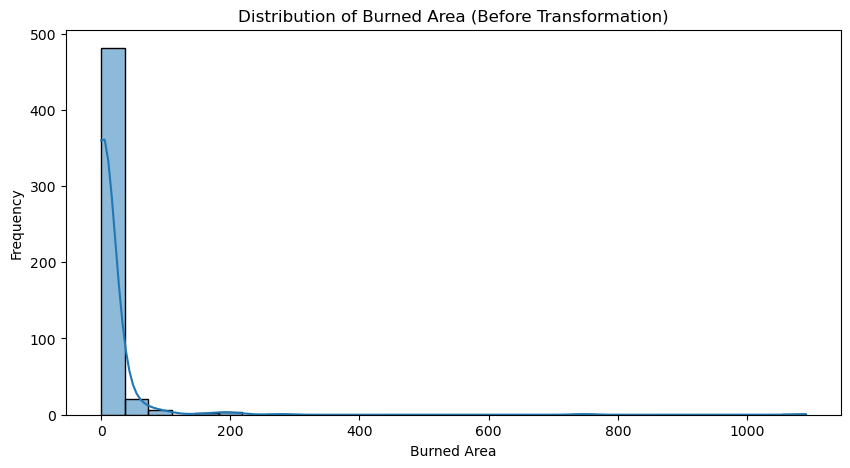

In [8]:
# Visualization of Target Variable
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df['area'], bins=30, kde=True)
plt.title('Distribution of Burned Area (Before Transformation)')
plt.xlabel('Burned Area')
plt.ylabel('Frequency')
plt.show()

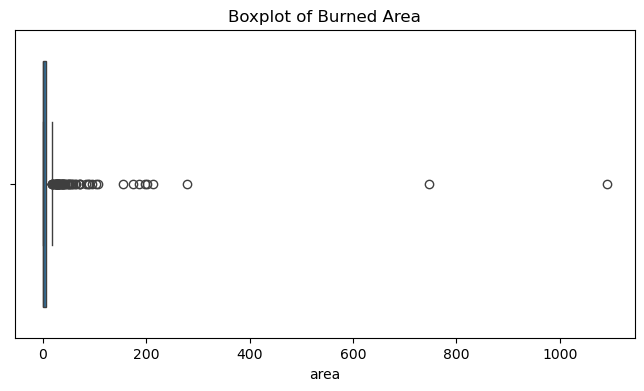

In [14]:
# Checking For Outliers (Extreme Values that deviate significantly from the rest of a dataset in a distribution)
plt.figure(figsize=(8,4))
sns.boxplot(x=df['area'])
plt.title('Boxplot of Burned Area')
plt.show()

In [12]:
# Inspecting Skewness Of Burnt Area

df["area"].skew()

np.float64(12.802213419146321)

#### Skewness in Burned Area

The area column is heavily skewed to the right, with a skewness value of 12.80. This means most fires burned only small areas, while a few spread across much larger areas.

In [22]:
# Target Variable Log Transformation
import numpy as np

df['area_log'] = np.log1p(df['area'])

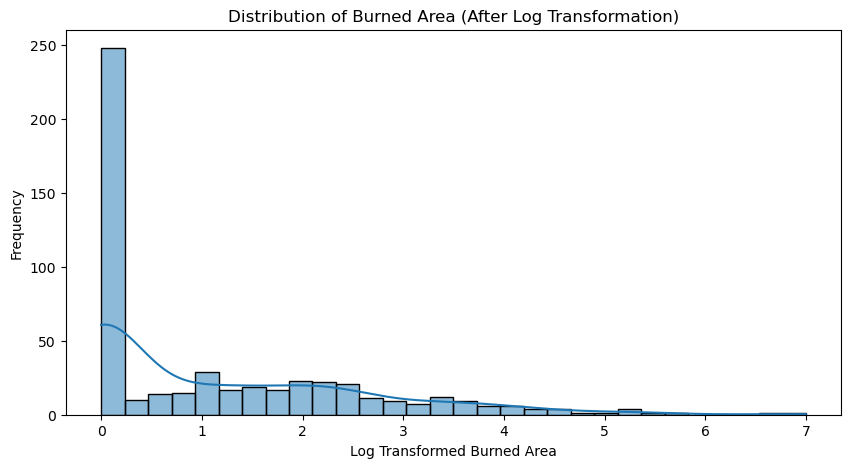

In [23]:
# Visualizing Transformed Target Variable

plt.figure(figsize=(10,5))
sns.histplot(df['area_log'], bins=30, kde=True)
plt.title('Distribution of Burned Area (After Log Transformation)')
plt.xlabel('Log Transformed Burned Area')
plt.ylabel('Frequency')
plt.show()

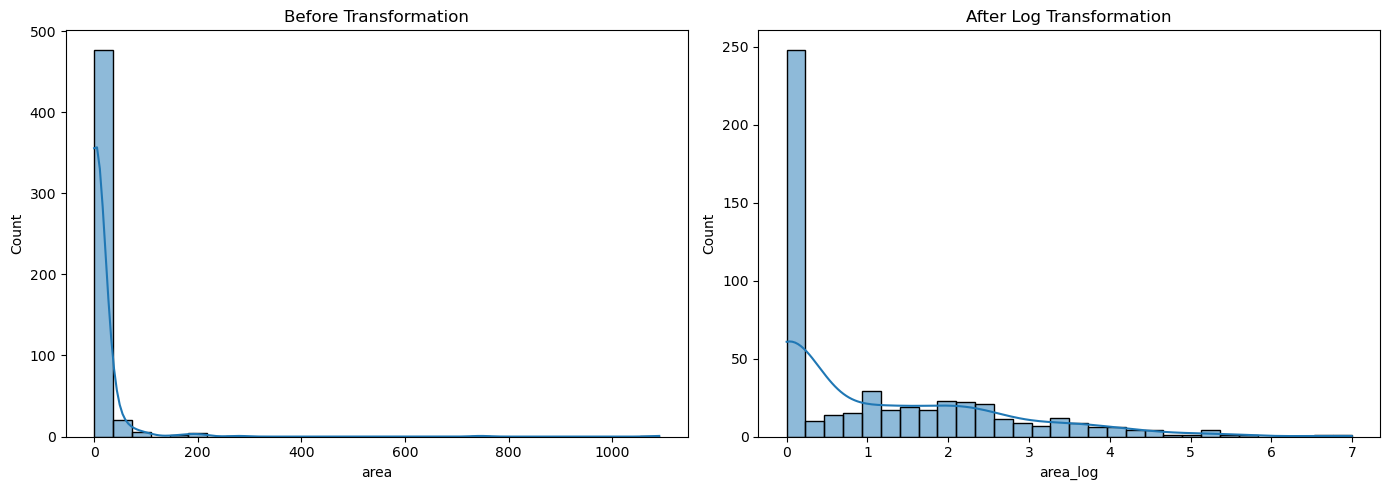

In [24]:
# Comparison of the before and after of the target Variable
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df['area'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Before Transformation')

sns.histplot(df['area_log'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('After Log Transformation')

plt.tight_layout()
plt.show()

#### Preparing the Target Variable

The area column was heavily skewed, with many small values and a few very large ones. This made the distribution uneven and could affect model performance.

To reduce this skewness and limit the effect of extreme values, I applied a log transformation (log1p) to the area column.

This made the distribution more balanced and better suited for further analysis and modeling.

## Exploring Weather Relationships

How temperature and humidity relates to wildfire burned area is examined.The goal is to identify whether these weather conditions show any visible pattern with how much land gets burned (area).

#### Temperature vs Burned Area

Are higher temperatures linked with larger wildfire burned areas?

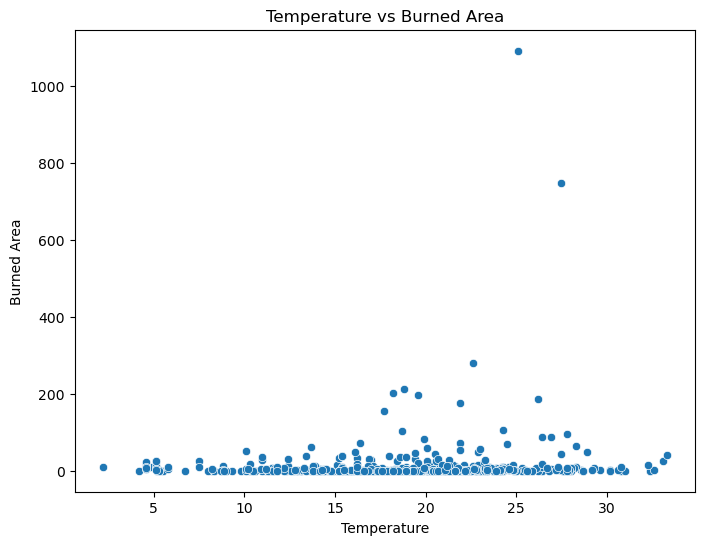

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_cleaned, x='temp', y='area')
plt.title('Temperature vs Burned Area')
plt.xlabel('Temperature')
plt.ylabel('Burned Area')
plt.show()

#### Interpretation

The scatter plot suggests a weak positive relationship between temperature and burned area. Most wildfire events are grouped around low burned area values, which means many fires remained small. However, a few larger wildfire events appear at higher temperatures, suggesting that warmer conditions may be linked to larger wildfires.

#### Insight

From this, temperature may play a role in wildfire spread, but it is not the only factor affecting burned area. While warmer conditions may support larger fires, most wildfire events still remain small. This suggests that other factors like humidity, wind, and overall fire conditions also affect how much land gets burned.   

#### Humidity vs Burned Area

Do humidity levels influence wildfire burned area?

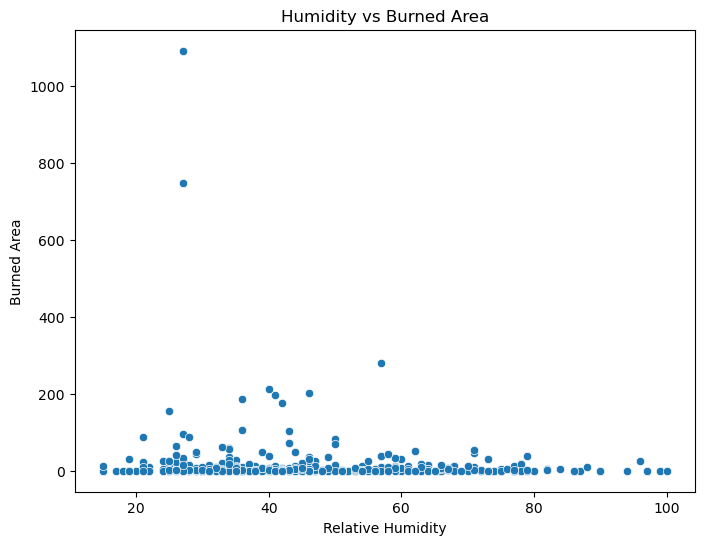

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_cleaned, x='RH', y='area')
plt.title('Humidity vs Burned Area')
plt.xlabel('Relative Humidity')
plt.ylabel('Burned Area')
plt.show()

#### Interpretation

The scatter plot shows a slight negative relationship between humidity and burned area. Wildfire events are mostly clustered around smaller burned areas, even across different humidity levels. Still, a few larger fires appear when humidity is lower, which suggests that drier air may be linked to wider wildfire spread.

#### Insight

This suggests that humidity may influence wildfire area size, especially under drier conditions. Lower humidity can make vegetation lose moisture more easily, which may allow fires to spread faster. Although, humidity alone does not explain wildfire size, which means other factors likely also contribute to how much land gets burned. 